# Table of Contents
- Types of Data in Machine Learning
- Intro to Exploratory Data Analysis


# Type of Data in Machine Learning


🔢 1. Numerical Data (Quantitative)

These are numbers where mathematical operations make sense.

**a) Continuous Data**
- Can take any value within a range (decimals allowed)
- Examples:
  - Height (170.5 cm)
  - Temperature (36.7°C)
  - Salary


**b) Discrete Data**
- Countable numbers (usually integers)
- Examples:
  - Number of students in a class
  - Number of cars
  - Number of purchases


🏷️ 2. Categorical Data (Qualitative)

These represent labels or categories, not numbers.

**a) Nominal Data**
- No order or ranking
- Examples:
  - Color (Red, Blue, Green)
  - Country
  - Gender
  
**b) Ordinal Data**
- Has a meaningful order, but differences are not measurable
- Examples:
  - Education level (High School < Bachelor < Master)
  - Rating (Low, Medium, High)
  
🔠 3. Binary Data
- Special type of categorical data with only two values
- Examples:
  - Yes / No
  - 0 / 1
  - True / False

🧾 4. Time-Series Data
- Data collected over time
- Important for forecasting problems
- Examples:
  - Stock prices over days
  - Daily temperature
  - Monthly sales


#### 🧠 Quick Summary Table:

| Type        | Subtype     | Example                |
| ----------- | ----------- | ---------------------- |
| Numerical   | Continuous  | Height, Temperature    |
| Numerical   | Discrete    | Number of students     |
| Categorical | Nominal     | Color, Country         |
| Categorical | Ordinal     | Rank, Education level  |
| Categorical | Binary      | Yes/No                 |
| Special     | Time-Series | Stock prices over time |


#### 💡 Why this matters in ML
- Numerical data → used directly in models
- Categorical data → needs encoding (like one-hot encoding)
- Ordinal data → can sometimes be mapped to numbers
- Time-series → needs special models (like ARIMA, LSTM)


# Introduction to Exploratory Data Analysis (EDA)
EDA is the process of analysing and visualising a dataset to summarise its key characteristics before applying any modelling or statistical techniques.

Think of it as getting to know your data before asking it to do something for you.

![EDA](https://miro.medium.com/v2/resize:fit:1400/1*YJB4BqnExQlJmFczd9J2dA.png)


## Steps of EDA

![Steps of EDA](https://media.geeksforgeeks.org/wp-content/uploads/20250806130212248170/exploratory_data_analysis_eda_2.webp)

# Understanding the Problem

![titanic](https://miro.medium.com/1*kK49KzkYEUYbFjVXrAEJxQ.jpeg)

### [Kaggle Titanic Dataset Link](https://www.kaggle.com/competitions/titanic/)

### Titanic - Machine Learning from Disaster


**Titanic Dataset Data Dictionary**

| Variable   | Definition                               | Key / Notes                                                                 |
|-----------|-----------------------------------------|---------------------------------------------------------------------------|
| survival  | Survival                                 | 0 = No, 1 = Yes                                                           |
| pclass    | Ticket class                             | 1 = 1st, 2 = 2nd, 3 = 3rd<br>**Notes:** Proxy for socio-economic status (SES): 1st = Upper, 2nd = Middle, 3rd = Lower |
| sex       | Sex                                      | -                                                                         |
| age       | Age in years                             | Fractional if less than 1; estimated ages may be in xx.5 format           |
| sibsp     | Number of siblings / spouses aboard      | **Notes:** Sibling = brother, sister, stepbrother, stepsister;<br>Spouse = husband, wife (mistresses and fiancés ignored) |
| parch     | Number of parents / children aboard      | **Notes:** Parent = mother, father;<br>Child = daughter, son, stepdaughter, stepson;<br>Children traveling only with a nanny have parch=0 |
| ticket    | Ticket number                            | -                                                                         |
| fare      | Passenger fare                           | -                                                                         |
| cabin     | Cabin number                             | -                                                                         |
| embarked  | Port of Embarkation                      | C = Cherbourg, Q = Queenstown, S = Southampton                            |



## Variable Notes

**pclass**
- A proxy for socio-economic status (SES)  
  - 1st = Upper  
  - 2nd = Middle  
  - 3rd = Lower  

**age**
- Age is fractional if less than 1  
- If the age is estimated, it may be in the form xx.5  

**sibsp**
- Defines family relations as:  
  - **Sibling:** brother, sister, stepbrother, stepsister  
  - **Spouse:** husband, wife (mistresses and fiancés were ignored)  

**parch**
- Defines family relations as:  
  - **Parent:** mother, father  
  - **Child:** daughter, son, stepdaughter, stepson  
- Some children traveled only with a nanny, so `parch = 0` for them


### **Dataset Understanding**
- `survival` → Target variable
- `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked` → Features
- `ticket`, `cabin` → Less useful (often need cleaning or feature engineering)

In short, the goal is to predict whether a passenger survived based on attributes like gender, age, passenger class, and other related features.

**N.B.**
- features -> model input
- target/label -> model output

## Import Necessary Libraries



In [ ]:
# data analysis and wrangling
import pandas as pd
import numpy as np
import random as rnd

# data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier

# others
import os

In [ ]:
# built in modules/library
import os
import random
import datetime

In [ ]:
# !pip install numpy
# !pip install pandas

## Loading The Data

In [ ]:
# mount google drive in colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_path  = "/content/drive/MyDrive/Colab Notebooks/dataset/titanic"
train_path = os.path.join(base_path, "train.csv")
test_path  = os.path.join(base_path, "test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
combine = [train_df, test_df]

## Exploring the dataset

In [ ]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
train_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
print(train_df.columns.values)

['PassengerId' 'Survived' 'Pclass' 'Name' 'Sex' 'Age' 'SibSp' 'Parch'
 'Ticket' 'Fare' 'Cabin' 'Embarked']


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Check for missing values
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
train_df['Survived'].value_counts()

,count
Survived,
0,549
1,342


#### **Which features are categorical?**

These values classify the samples into sets of similar samples. Within categorical features are the values nominal, ordinal, ratio, or interval based? Among other things this helps us select the appropriate plots for visualization.

- **Categorical:** `Survived`, `Sex`, and `Embarked`.
- **Ordinal:** `Pclass`.

#### **Which features are numerical?**

Which features are numerical? These values change from sample to sample. Within numerical features are the values discrete, continuous, or timeseries based? Among other things this helps us select the appropriate plots for visualization.

- **Continous:** `Age`, `Fare`.
- **Discrete:** `SibSp`, `Parch`.


#### **Which features are mixed data types?**

Numerical, alphanumeric data within same feature. These are candidates for correcting goal.

- `Ticket` is a mix of **numeric** and **alphanumeric** data types.
- `Cabin` is **alphanumeric**.

#### **Which features may contain errors or typos?**

This is harder to review for a large dataset, however reviewing a few samples from a smaller dataset may just tell us outright, which features may require correcting.

- `Name` feature may contain errors or typos as there are several ways used to describe a name including titles, round brackets, and quotes used for alternative or short names.


#### **Which features contain blank, null or empty values?**

These will require correcting.

- `Cabin`, `Age`, `Embarked` features contain a number of null values in that order for the training dataset.
- `Cabin`,  `Age` are incomplete in case of test dataset.

#### **What are the data types for various features?**

Helping us during converting goal.

- Seven features are **integer** or **floats**. Six in case of test dataset.
- Five features are **strings (object)**.

In [ ]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
train_df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [ ]:
train_df["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [ ]:
train_df["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


## Bivariate Analysis: Relationship Between Features and Target Variable

In this section, we look at how different categories—like a passenger's class or gender affected their chances of surviving. By grouping these features and calculating the average of the Survived column, we can see clear patterns in the data. So, Let's now analyze how individual features (`pclass`, `sex`, `age` etc) relate to the target variable (`Survived`) by computing the average survival rate across different categories.

In [ ]:
train_df[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [ ]:
train_df[["Sex", "Survived"]].groupby(['Sex'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [ ]:
train_df[["SibSp", "Survived"]].groupby(['SibSp'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [ ]:
train_df[["Parch", "Survived"]].groupby(['Parch'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


In [ ]:
train_df["family_size"] = train_df["SibSp"] + train_df["Parch"]
train_df[["family_size", "Survived"]].groupby(["family_size"], as_index=False).mean().sort_values(by="Survived", ascending=False)


,family_size,Survived
3,3,0.724138
2,2,0.578431
1,1,0.552795
6,6,0.333333
0,0,0.303538
4,4,0.200000
5,5,0.136364
7,7,0.000000
8,10,0.000000


In [ ]:
train_df["AgeGroup"] = pd.cut(
    train_df["Age"],
    bins=[0, 13, 30, 50, 100],
    labels=["Child", "Young", "Adult", "Senior"],
    right=False  # makes intervals: [0-13), [13-30), etc.
)

train_df[["AgeGroup", "Survived"]].groupby(["AgeGroup"], as_index=False).mean().sort_values(by="Survived", ascending=False)

/tmp/ipykernel_4454/2273605767.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df[["AgeGroup", "Survived"]].groupby(["AgeGroup"], as_index=False).mean().sort_values(by="Survived", ascending=False)


,AgeGroup,Survived
0,Child,0.579710
2,Adult,0.417969
1,Young,0.368254
3,Senior,0.364865


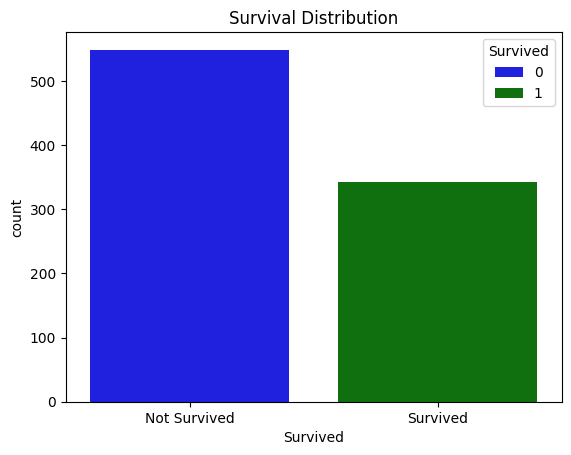

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot class distribution
sns.countplot(x='Survived', hue='Survived', data=train_df, palette=["blue", "green"])
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.title("Survival Distribution")
plt.show()

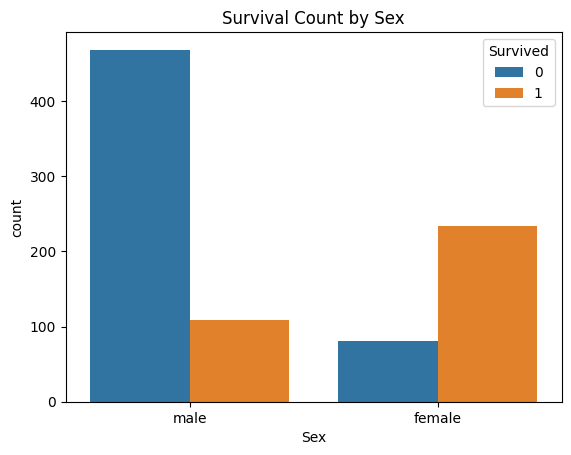

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sex', hue='Survived', data=train_df)
plt.title('Survival Count by Sex')
plt.show()

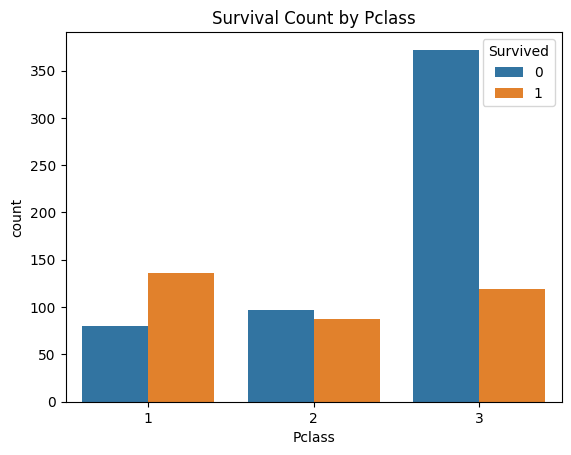

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Pclass', hue='Survived', data=train_df)
plt.title('Survival Count by Pclass')
plt.show()

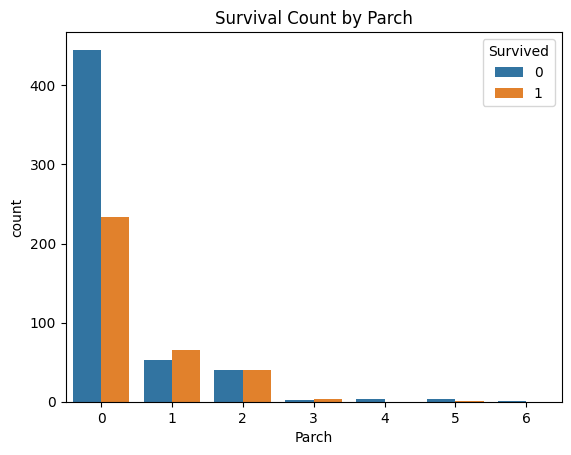

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Parch', hue='Survived', data=train_df)
plt.title('Survival Count by Parch')
plt.show()

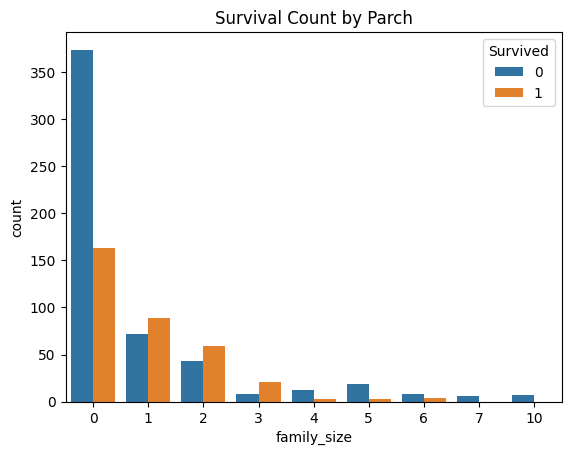

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='family_size', hue='Survived', data=train_df)
plt.title('Survival Count by Parch')
plt.show()

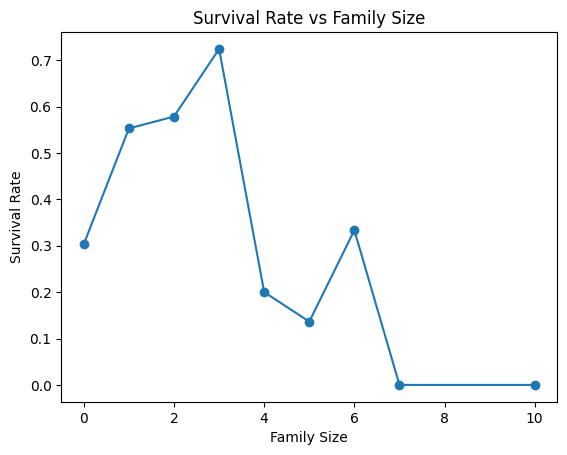

In [ ]:
df_plot = train_df[["family_size", "Survived"]] \
    .groupby("family_size", as_index=False) \
    .mean() \
    .sort_values("family_size")

plt.plot(df_plot["family_size"], df_plot["Survived"], marker='o')
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.title("Survival Rate vs Family Size")
plt.show()

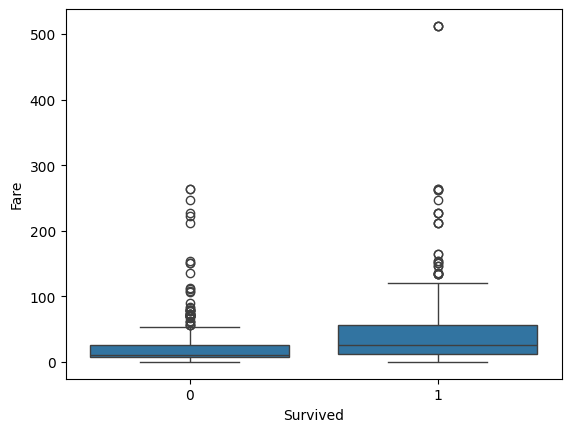

In [ ]:
import seaborn as sns

sns.boxplot(x="Survived", y="Fare", data=train_df);

<Axes: xlabel='Fare', ylabel='Density'>

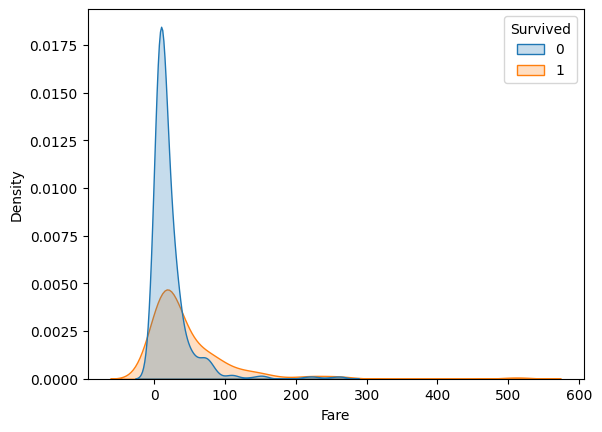

In [ ]:
sns.kdeplot(data=train_df, x="Fare", hue="Survived", fill=True)

<Axes: xlabel='Survived', ylabel='Age'>

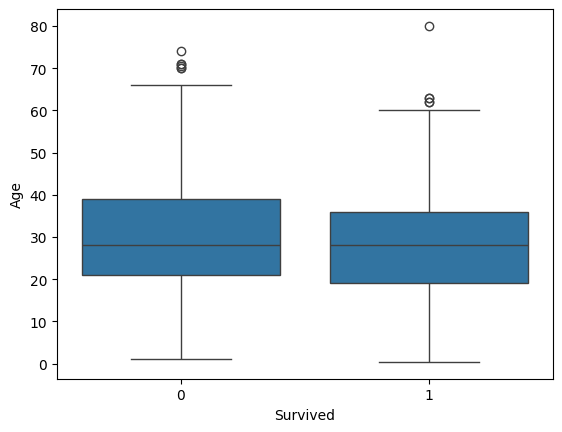

In [ ]:
sns.boxplot(x="Survived", y="Age", data=train_df)


<Axes: xlabel='Survived', ylabel='Age'>

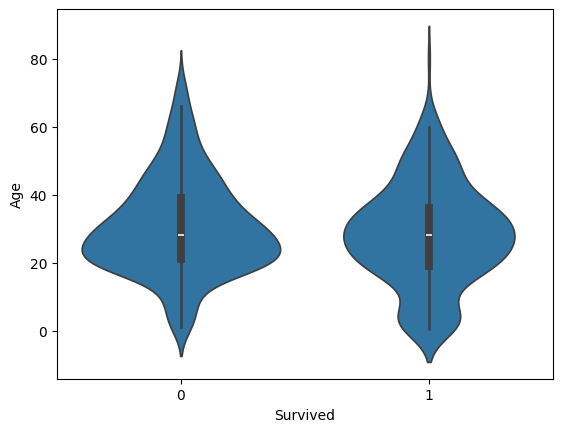

In [ ]:
sns.violinplot(x="Survived", y="Age", data=train_df)

In [ ]:
median_survived = train_df[train_df['Survived'] == 1]['Age'].median()
median_not_survived = train_df[train_df['Survived'] == 0]['Age'].median()

print(f"Median age of survivors: {median_survived}")
print(f"Median age of non-survivors: {median_not_survived}")

Median age of survivors: 28.0
Median age of non-survivors: 28.0



## Next Steps for Supervised Learning
- Handle missing values (Age, Cabin, Embarked)
- Encode categorical variables (Sex, Embarked)
- Feature Engineering (e.g., Family Size, Title from Name)
- Train/Test Split
- Train a classifier (e.g., Logistic Regression)
- Evaluate using accuracy, precision, recall